In [25]:
import pandas as pd
project = pd.read_csv("customer_shopping_data.csv.zip")
print (project)

      invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99452    I219422     C441542  Female   45         Souvenir         5    58.65   
99453    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99454    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99455    I702964     C800631    Male   56       Technology         4  4200.00   
99456    I232867     C273973  Female   36         Souvenir         3    35.19   

      payment_method invoic

In [26]:
print("\n  DESCRIPTION \n")
print (project.describe())


  DESCRIPTION 

                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450000
50%       43.000000      3.000000    203.300000
75%       56.000000      4.000000   1200.320000
max       69.000000      5.000000   5250.000000


In [27]:
print("\n  NULL \n ")
print (project.isnull().sum())


  NULL 
 
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


In [28]:
print("\n  INFO \n")
print (project.info)


  INFO 

<bound method DataFrame.info of       invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99452    I219422     C441542  Female   45         Souvenir         5    58.65   
99453    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99454    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99455    I702964     C800631    Male   56       Technology         4  4200.00   
99456    I232867     C273973  Female   36         Souvenir         

In [29]:
print("\n  DUPLICATE \n")
print (project.duplicated().sum())


  DUPLICATE 

0


In [30]:
print("\n  SHAPE (rows,column) \n")
print (project.shape)


  SHAPE (rows,column) 

(99457, 10)


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np


  QUESTION 1 


  1. Revenue performance 


  How is total sales value distributed across the different product categories, and which categories contribute the greatest share of overall sales? 

0         7502.00
1         5401.53
2          300.08
3        15004.25
4          242.40
           ...   
99452      293.25
99453       20.92
99454       20.92
99455    16800.00
99456      105.57
Length: 99457, dtype: float64
category
Clothing           1.139968e+08
Shoes              6.655345e+07
Technology         5.786235e+07
Cosmetics          6.792863e+06
Toys               3.980426e+06
Food & Beverage    8.495351e+05
Books              8.345529e+05
Souvenir           6.358247e+05
Name: total_sales, dtype: float64


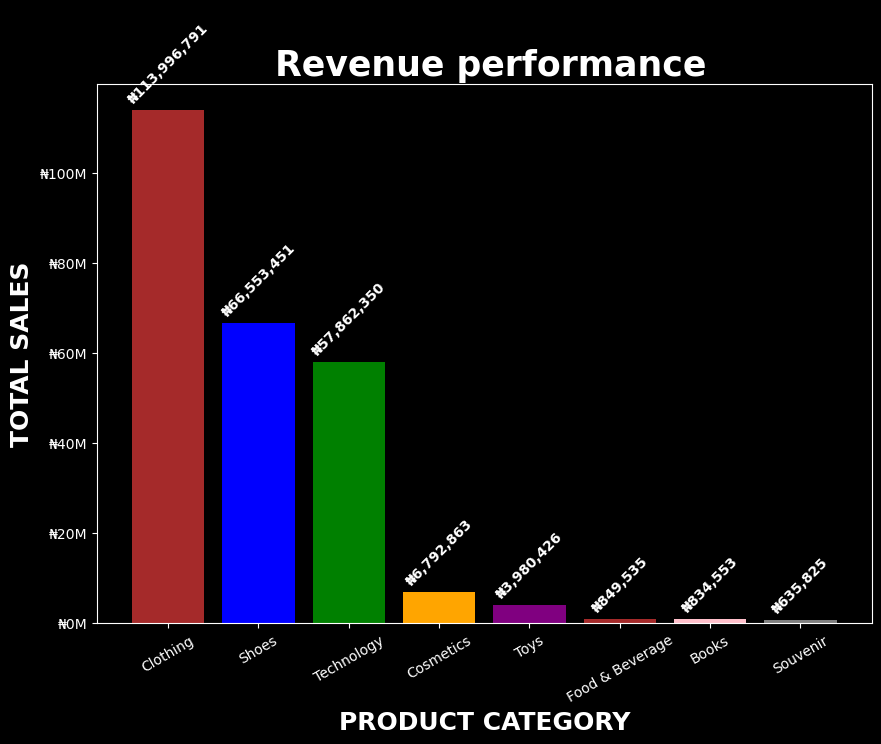

In [103]:
# QUESTION
print("\n  QUESTION 1 \n")
print("\n  1. Revenue performance \n")
print("\n  How is total sales value distributed across the different product categories, and which categories contribute the greatest share of overall sales? \n")

# CREATING TOTAL SALES COLUMN
project["total_sales"] = (project["price"]*project["quantity"])
print(total_sales)

# GROUPING AND SORTING
revenue = project.groupby("category")["total_sales"].sum().sort_values(ascending=False)
print (revenue)

# dark barkdround chart
plt.style.use('dark_background')

# TITLE,SIZE,FONTSIZE,COLOR AND CHART
plt.figure(figsize=(10,7))
plt.title("\n Revenue performance", fontweight='bold', fontsize=25 )
bars= plt.bar(revenue.index, revenue.values,color = ['brown', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan'])

#  ROTATE AND LABEL
plt.xticks(rotation =30)
plt.ylabel("TOTAL SALES",fontweight='bold', fontsize=18)
plt.xlabel("PRODUCT CATEGORY",fontweight='bold', fontsize=18)

# This function removes 1e8 and 0.8 - it shows 20M, 40M, 80M
def millions(x, pos):
    return f'₦{x/1e6:.0f}M'

# THIS LINE REMOVES 1e8!
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

# THIS ADDS DATA LABELS ON TOP OF EACH BAR
plt.bar_label(bars, labels=[f'₦{v:,.0f}' for v in revenue.values], padding=3, fontsize=10, rotation=45 , fontweight='bold')

plt.show()



  QUESTION 2 


  2. Volume vs value 

 Do the categories that sell the highest number of items also generate the highest sales value, or is there a difference between sales volume and sales value?


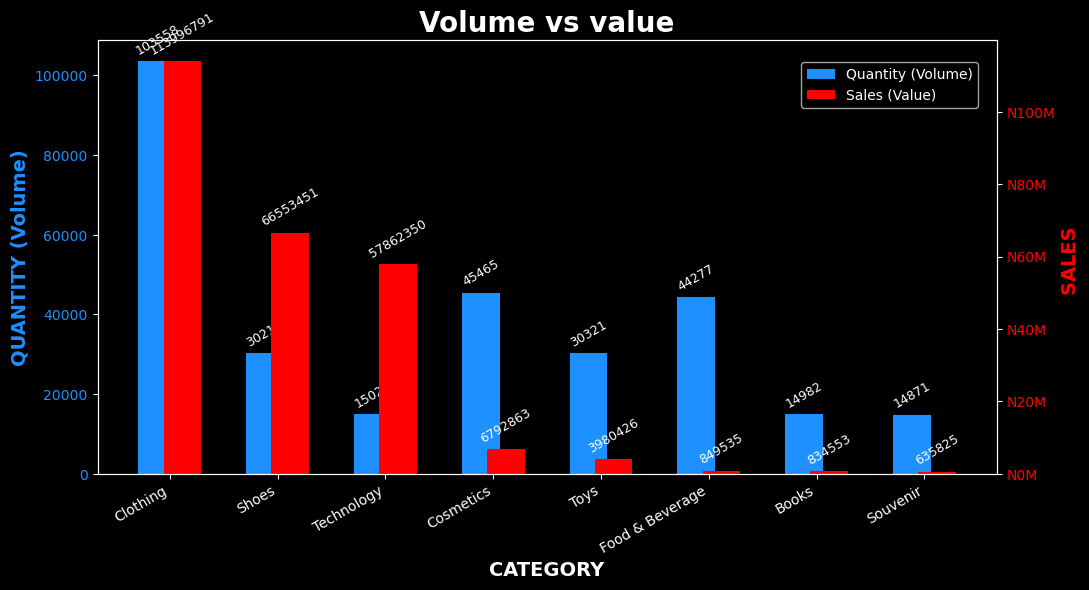

                 total_quantity   total_sales
category                                     
Clothing                 103558  1.139968e+08
Shoes                     30217  6.655345e+07
Technology                15021  5.786235e+07
Cosmetics                 45465  6.792863e+06
Toys                      30321  3.980426e+06
Food & Beverage           44277  8.495351e+05
Books                     14982  8.345529e+05
Souvenir                  14871  6.358247e+05


In [134]:

# QUESTION
print("\n  QUESTION 2 \n")
print("\n  2. Volume vs value ")
print("\n Do the categories that sell the highest number of items also generate the highest sales value, or is there a difference between sales volume and sales value?")

# 2. Group
volume_vs_value = project.groupby("category").agg(
    total_quantity = ("quantity", "sum"),
    total_sales = ("total_sales", "sum")
).sort_values("total_sales", ascending=False)

# 3. Positions
x = np.arange(len(volume_vs_value))
width = 0.35

# 4. Plot with 2 Y-axis
fig, ax1 = plt.subplots(figsize=(11,6))
plt.style.use('dark_background')

# Blue = Quantity on left axis
bars1 = ax1.bar(x - width/3, volume_vs_value["total_quantity"], width, label='Quantity (Volume)', color='dodgerblue')
ax1.set_ylabel("QUANTITY (Volume)", fontweight='bold', fontsize=14, color='dodgerblue')
ax1.tick_params(axis='y', labelcolor='dodgerblue')

# Red = Sales on right axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/3, volume_vs_value["total_sales"], width, label='Sales (Value)', color='red')
ax2.set_ylabel("SALES ", fontweight='bold', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Data labels for Quantity bars
ax1.bar_label(bars1, fmt='%.0f', padding=3, fontsize=9 ,rotation =30)

# Data labels for Sales bars
ax2.bar_label(bars2, fmt='%.0f', padding=3, fontsize=9, rotation =30)

# Millions formatter for sales axis
def millions(x, pos):
    return f'N{x/1e6:.0f}M'
ax2.yaxis.set_major_formatter(FuncFormatter(millions))

# X axis - FIX for category names
plt.title("Volume vs value", fontweight='bold', fontsize=20)
ax1.set_xticks(x)
ax1.set_xticklabels(volume_vs_value.index, rotation=30, ha='right')
ax1.set_xlabel("CATEGORY", fontweight='bold', fontsize=14)     # SECOND AXIS FONT COLOUR 

# Legend
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

#layout
plt.tight_layout()
plt.show()

print(volume_vs_value)


QUESTION 2

2. Volume vs Value

Do the categories that sell the highest number of items also generate the highest sales value, or is there a difference between sales volume and sales value?


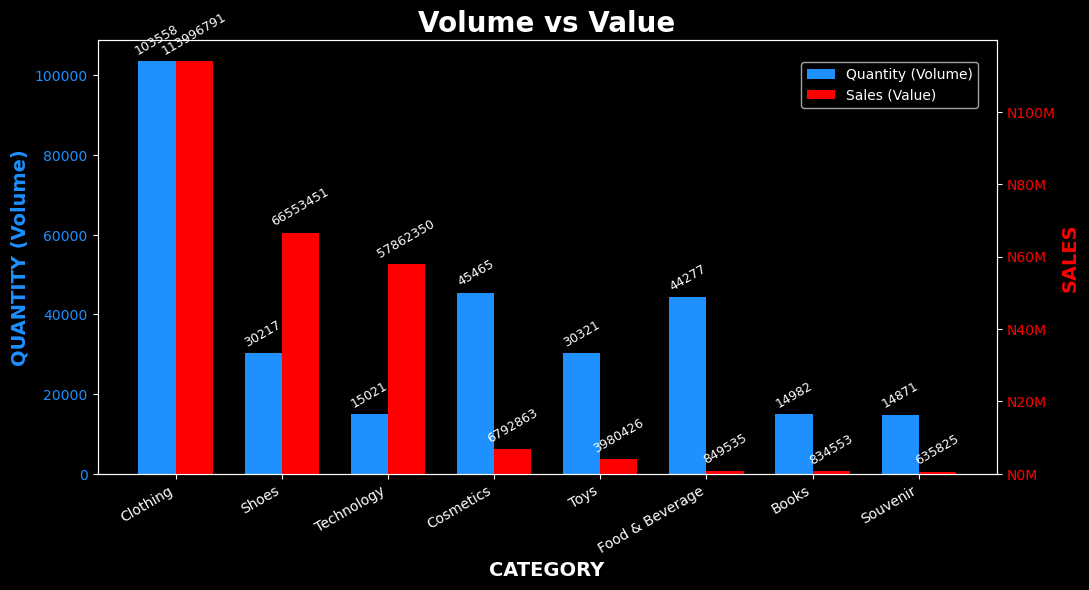

                 total_quantity   total_sales
category                                     
Clothing                 103558  1.139968e+08
Shoes                     30217  6.655345e+07
Technology                15021  5.786235e+07
Cosmetics                 45465  6.792863e+06
Toys                      30321  3.980426e+06
Food & Beverage           44277  8.495351e+05
Books                     14982  8.345529e+05
Souvenir                  14871  6.358247e+05


In [135]:
# Display the question we are answering
print("\nQUESTION 2\n")
print("2. Volume vs Value")
print("\nDo the categories that sell the highest number of items also generate the highest sales value, or is there a difference between sales volume and sales value?")

# Group the dataset by product category
# This puts all transactions belonging to the same category together
volume_vs_value = project.groupby("category").agg(
    
    # Add together the quantity sold in each category
    total_quantity=("quantity", "sum"),
    
    # Add together the total sales value in each category
    total_sales=("total_sales", "sum")
    
# Sort the categories from the highest sales value to the lowest
).sort_values("total_sales", ascending=False)


# Create a numerical position for each category on the x-axis
# For example, if there are 5 categories, x will be [0, 1, 2, 3, 4]
x = np.arange(len(volume_vs_value))

# Control the width of each bar
width = 0.35


# Create the chart figure and the first plotting axis
# fig represents the entire chart/figure
# ax1 represents the first set of axes, which we will use for quantity
fig, ax1 = plt.subplots(figsize=(11, 6))

# Apply the dark background style to the chart
plt.style.use("dark_background")


# Create the quantity bars on the left Y-axis
# x - width/2 moves these bars slightly to the left
# This makes room for the sales bars beside them
bars1 = ax1.bar(
    x - width / 2,
    volume_vs_value["total_quantity"],
    width,
    label="Quantity (Volume)",
    color="dodgerblue"
)

# Give the left Y-axis a label
ax1.set_ylabel(
    "QUANTITY (Volume)",
    fontweight="bold",
    fontsize=14,
    color="dodgerblue"
)

# Make the numbers on the left Y-axis blue
ax1.tick_params(axis="y", labelcolor="dodgerblue")


# Create a second Y-axis on the right side
# twinx() allows us to have another Y-axis while keeping the same X-axis
# This is useful because quantity and sales have very different scales
ax2 = ax1.twinx()


# Create the sales bars on the right Y-axis
# x + width/2 moves these bars slightly to the right
# Together with the quantity bars, this creates grouped bars
bars2 = ax2.bar(
    x + width / 2,
    volume_vs_value["total_sales"],
    width,
    label="Sales (Value)",
    color="red"
)

# Give the right Y-axis a label
ax2.set_ylabel(
    "SALES",
    fontweight="bold",
    fontsize=14,
    color="red"
)

# Make the numbers on the right Y-axis red
ax2.tick_params(axis="y", labelcolor="red")


# Add the actual quantity values on top of the quantity bars
# bars1 refers to all the quantity bars we created above
# %.0f means display the number with no decimal places
# padding=3 gives a little space between the bar and the label
# rotation=30 tilts the labels slightly
ax1.bar_label(
    bars1,
    fmt="%.0f",
    padding=3,
    fontsize=9,
    rotation=30
)


# Add the actual sales values on top of the sales bars
ax2.bar_label(
    bars2,
    fmt="%.0f",
    padding=3,
    fontsize=9,
    rotation=30
)


# Create a function to format sales-axis numbers in millions
# x is the number being displayed on the axis
# pos represents the position of that number on the axis
def millions(x, pos):
    return f"N{x / 1e6:.0f}M"


# Apply the millions formatting function to the right Y-axis
# This changes values such as 1000000 into N1M
ax2.yaxis.set_major_formatter(FuncFormatter(millions))


# Add the chart title
plt.title(
    "Volume vs Value",
    fontweight="bold",
    fontsize=20
)


# Tell Matplotlib where the category positions are
ax1.set_xticks(x)


# Replace the numerical positions with the actual category names
# rotation=30 tilts long category names
# ha="right" aligns the labels neatly
ax1.set_xticklabels(
    volume_vs_value.index,
    rotation=30,
    ha="right"
)


# Add a label to the X-axis
ax1.set_xlabel(
    "CATEGORY",
    fontweight="bold",
    fontsize=14
)


# Create one legend for both sets of bars
# fig.legend() allows the legend to include items from both ax1 and ax2
# loc="upper right" places the legend near the top-right
# bbox_to_anchor gives more precise control over its position
fig.legend(
    loc="upper right",
    bbox_to_anchor=(0.9, 0.9)
)


# Automatically adjust the spacing so labels and titles do not overlap
plt.tight_layout()


# Display the finished chart
plt.show()


# Print the summary table so we can see the actual numbers behind the chart
print(volume_vs_value)


QUESTION 3

3. Shopping Mall Performance

Which shopping malls generate the highest total sales, and do malls with more transactions also generate more sales?
                   highest_sales  transactions
shopping_mall                                 
Cevahir AVM          12645138.20          4991
Emaar Square Mall    12406100.29          4811
Forum Istanbul       12303921.24          4947
Istinye Park         24618827.68          9781
Kanyon               50554231.10         19823
Mall of Istanbul     50872481.68         19943
Metrocity            37302787.33         15011
Metropol AVM         25379913.19         10161
Viaport Outlet       12521339.72          4914
Zorlu Center         12901053.82          5075


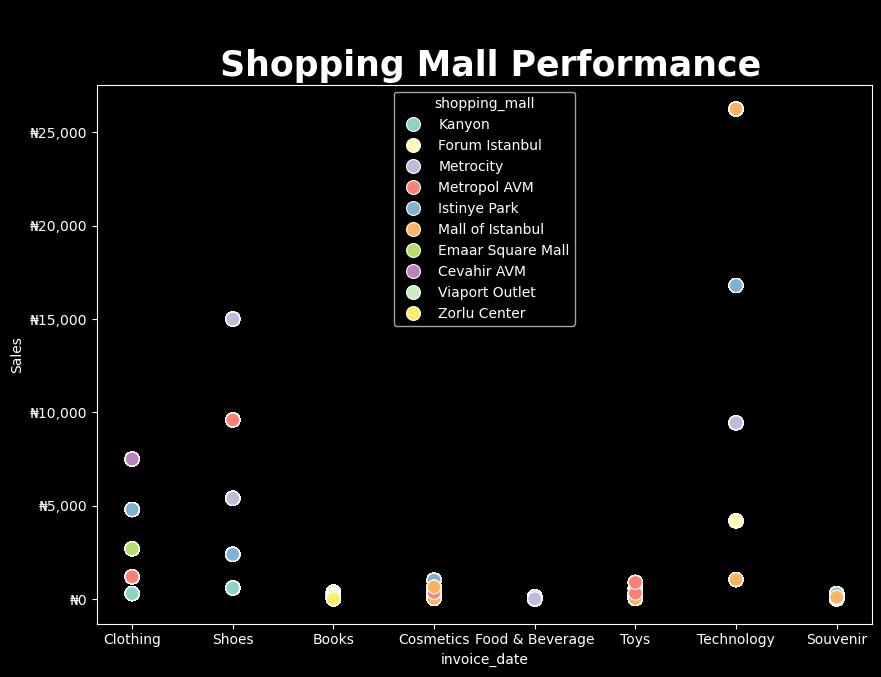

In [143]:

print("\nQUESTION 3\n")
print("3. Shopping Mall Performance")
print("\nWhich shopping malls generate the highest total sales, and do malls with more transactions also generate more sales?")

malls = project.groupby("shopping_mall").agg(
    highest_sales =("total_sales","sum"),
    transactions = ("category","count")
)

print (malls)

# dark barkdround chart
plt.style.use('dark_background')

# TITLE,SIZE,FONTSIZE,COLOR AND CHART
plt.figure(figsize=(10,7))
plt.title("\n Shopping Mall Performance", fontweight='bold', fontsize=25 )

sns.scatterplot(
     x="category",
    y="total_sales",
   data=project,
    hue="shopping_mall" ,     #color in scatterplot(you have to input another column) 
    s =100           #to make the bubbles bigger
)
# to naira sign
from matplotlib.ticker import FuncFormatter
def naira(x,money):
    return f"₦{x:,.0f}" 
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(naira)
)
#title

plt.xlabel("invoice_date")
plt.ylabel("Sales")

plt.show()




QUESTION 4

4. Customer Spending by Demographics

How does average transaction value vary across customer age groups and gender, and which demographic segment has the highest average spend per transaction?

Average transaction value by age group and gender:
   age_group  gender  average_transaction_value
0      18-24  Female                2555.444991
1      18-24    Male                2369.370552
2      25-34  Female                2486.726442
3      25-34    Male                2533.510757
4      35-44  Female                2548.663448
5      35-44    Male                2630.451297
6      45-54  Female                2521.026418
7      45-54    Male                2570.492642
8      55-64  Female                2543.312193
9      55-64    Male                2478.815234
10       65+  Female                2484.621450
11       65+    Male                2617.546034

Highest average spend per transaction: 35-44 / Male
Average transaction value: 2,630.45 TL


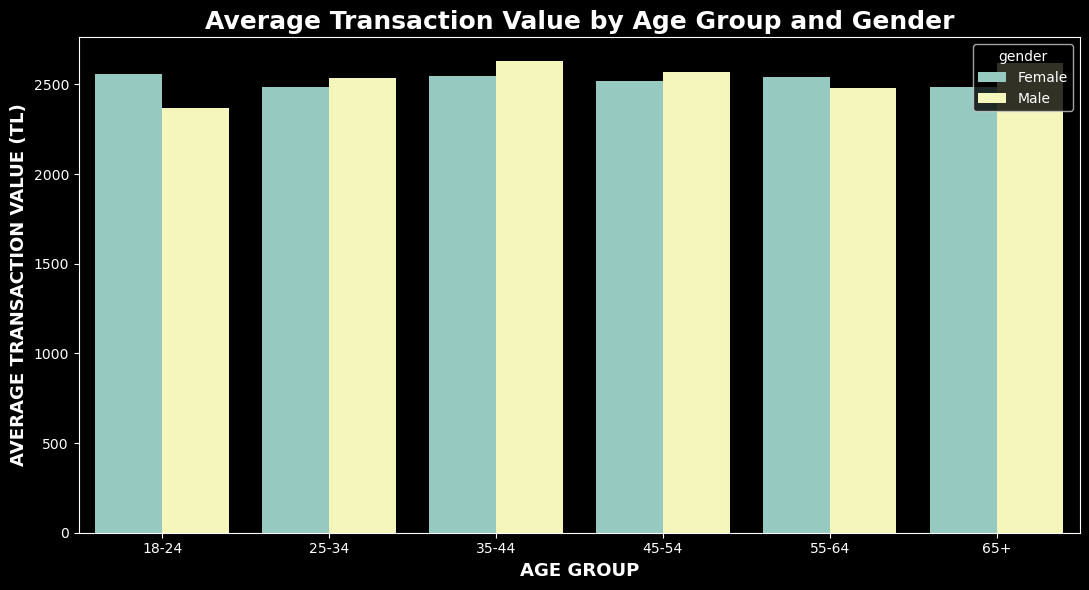

In [149]:
# Display the question we are answering
print("\nQUESTION 4\n")
print("4. Customer Spending by Demographics")
print("\nHow does average transaction value vary across customer age groups and gender, and which demographic segment has the highest average spend per transaction?")


# Create age groups from the customer's age
project["age_group"] = pd.cut(
    project["age"],
    bins=[0, 24, 34, 44, 54, 64, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)


# Calculate the average transaction value for each age group and gender
age_gender_spending = project.groupby(
    ["age_group", "gender"],
    observed=True
).agg(
    average_transaction_value=("total_sales", "mean")
).reset_index()


# Display the calculated values
print("\nAverage transaction value by age group and gender:")
print(age_gender_spending)


# Find the demographic group with the highest average transaction value
top_segment = age_gender_spending.loc[
    age_gender_spending["average_transaction_value"].idxmax()
]

print(
    f"\nHighest average spend per transaction: "
    f"{top_segment['age_group']} / {top_segment['gender']}"
)

print(
    f"Average transaction value: "
    f"{top_segment['average_transaction_value']:,.2f} TL"
)


# Create the grouped bar chart
# Each age group will have two bars: one for Female and one for Male
plt.figure(figsize=(11, 6))

sns.barplot(
    data=age_gender_spending,
    x="age_group",
    y="average_transaction_value",
    hue="gender"
)

# Add the chart title
plt.title(
    "Average Transaction Value by Age Group and Gender",
    fontweight="bold",
    fontsize=18
)

# Label the X-axis
plt.xlabel(
    "AGE GROUP",
    fontweight="bold",
    fontsize=13
)

# Label the Y-axis
plt.ylabel(
    "AVERAGE TRANSACTION VALUE (TL)",
    fontweight="bold",
    fontsize=13
)

# Rotate nothing because the age-group labels are already short
plt.xticks(rotation=0)

# Make sure the chart fits neatly
plt.tight_layout()

# Display the chart
plt.show()


QUESTION 5

5. Gender and Category Preferences

How do product-category preferences differ between male and female customers, and which categories show the strongest gender differences in purchasing behavior?

Total quantity purchased by category and gender:
           category  gender  total_quantity
0             Books  Female            8776
1             Books    Male            6206
2          Clothing  Female           62039
3          Clothing    Male           41519
4         Cosmetics  Female           27261
5         Cosmetics    Male           18204
6   Food & Beverage  Female           26362
7   Food & Beverage    Male           17915
8             Shoes  Female           17906
9             Shoes    Male           12311
10         Souvenir  Female            8976
11         Souvenir    Male            5895
12       Technology  Female            8977
13       Technology    Male            6044
14             Toys  Female           18362
15             Toys    Male         

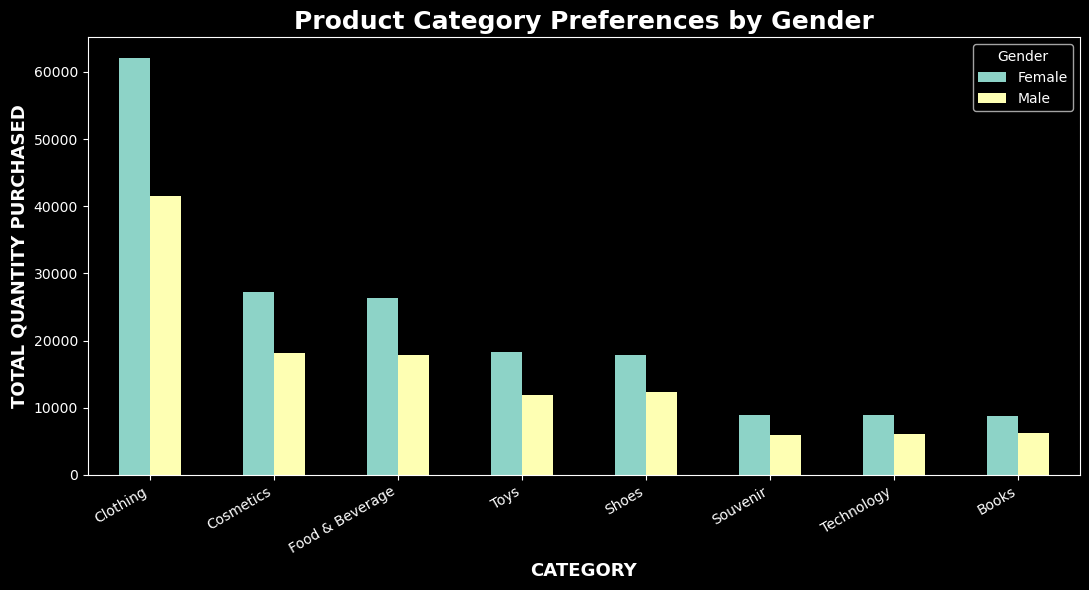

In [150]:
# Display the question we are answering
print("\nQUESTION 5\n")
print("5. Gender and Category Preferences")
print("\nHow do product-category preferences differ between male and female customers, and which categories show the strongest gender differences in purchasing behavior?")

# Group the data by category and gender
# Then calculate the total quantity purchased
gender_category = project.groupby(["category", "gender"]).agg(
    total_quantity=("quantity", "sum")
).reset_index()

# Display the result
print("\nTotal quantity purchased by category and gender:")
print(gender_category)

# Create a table where gender becomes separate columns
gender_pivot = gender_category.pivot(
    index="category",
    columns="gender",
    values="total_quantity"
).fillna(0)

# Calculate the absolute difference between male and female purchases
gender_pivot["gender_difference"] = (
    gender_pivot["Female"] - gender_pivot["Male"]
).abs()

# Sort from the largest gender difference to the smallest
gender_pivot = gender_pivot.sort_values(
    "gender_difference",
    ascending=False
)

print("\nCategories with the strongest gender differences:")
print(gender_pivot)

# Create a grouped bar chart
gender_pivot[["Female", "Male"]].plot(
    kind="bar",
    figsize=(11, 6)
)

# Add chart title
plt.title(
    "Product Category Preferences by Gender",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.xlabel("CATEGORY", fontweight="bold", fontsize=13)
plt.ylabel("TOTAL QUANTITY PURCHASED", fontweight="bold", fontsize=13)

# Rotate category names so they are easier to read
plt.xticks(rotation=30, ha="right")

# Add the legend
plt.legend(title="Gender")

plt.tight_layout()
plt.show()


QUESTION 6

6. Price vs Quantity

How does unit price relate to the quantity purchased per transaction, and do customers tend to purchase fewer units when the unit price is higher?

Correlation between unit price and quantity purchased: 0.345
Interpretation: Higher-priced items tend to be associated with higher quantities purchased.


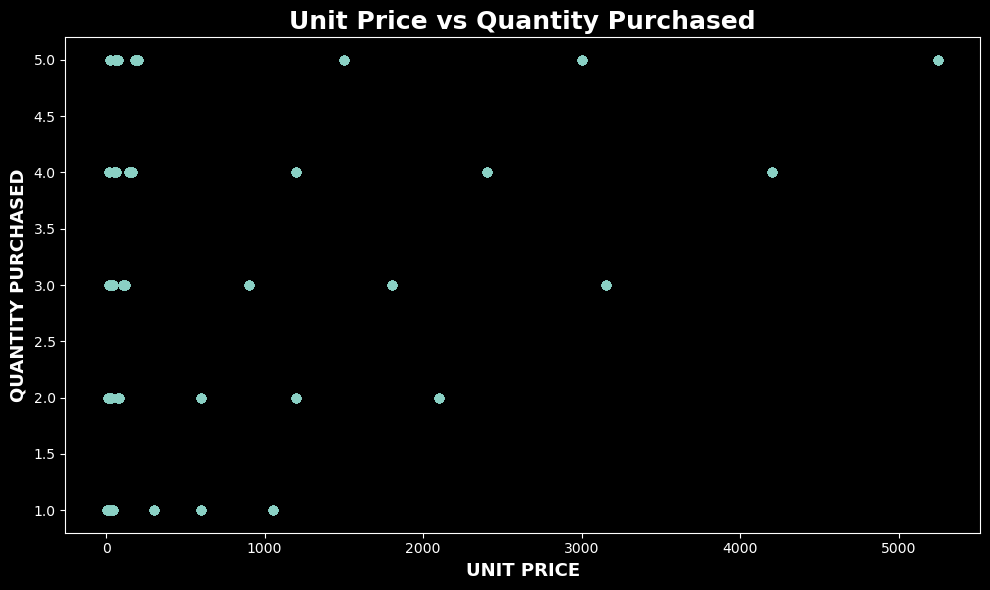

In [151]:
# Display the question we are answering
print("\nQUESTION 6\n")
print("6. Price vs Quantity")
print("\nHow does unit price relate to the quantity purchased per transaction, and do customers tend to purchase fewer units when the unit price is higher?")

# Calculate the correlation between price and quantity
price_quantity_correlation = project["price"].corr(
    project["quantity"]
)

# Display the correlation
print(
    f"\nCorrelation between unit price and quantity purchased: "
    f"{price_quantity_correlation:.3f}"
)

# Give a simple interpretation
if price_quantity_correlation < 0:
    print("Interpretation: Higher-priced items tend to be associated with lower quantities purchased.")
elif price_quantity_correlation > 0:
    print("Interpretation: Higher-priced items tend to be associated with higher quantities purchased.")
else:
    print("Interpretation: There is little to no linear relationship between price and quantity.")

# Create a scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    project["price"],
    project["quantity"],
    alpha=0.3
)

# Add chart title
plt.title(
    "Unit Price vs Quantity Purchased",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.xlabel("UNIT PRICE", fontweight="bold", fontsize=13)
plt.ylabel("QUANTITY PURCHASED", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.show()


QUESTION 7

7. Sales Over Time

How does total sales value change over the 2021–2023 period, and are there identifiable months or periods when customer spending increases or decreases?

Monthly sales:
            total_sales
month_year             
2021-01      9641614.62
2021-02      8772315.22
2021-03      9455359.38
2021-04      9389541.54
2021-05      9771756.97
2021-06      9286271.35
2021-07     10311119.68
2021-08      9630655.70
2021-09      9188165.62
2021-10     10263015.06
2021-11      9265555.29
2021-12      9585200.16
2022-01      9764311.14
2022-02      8344111.92
2022-03      9986685.16
2022-04      9326144.44
2022-05      9947574.13
2022-06      9647503.95
2022-07     10067602.95
2022-08      9651705.59
2022-09      9607629.29
2022-10     10282075.37
2022-11      8941584.66
2022-12      9869885.48
2023-01      9485599.83
2023-02      9508662.96
2023-03      2514146.79

Highest sales period: 2021-07 (10,311,119.68 TL)
Lowest sales period: 2023-03 (2,514,146.79 TL)


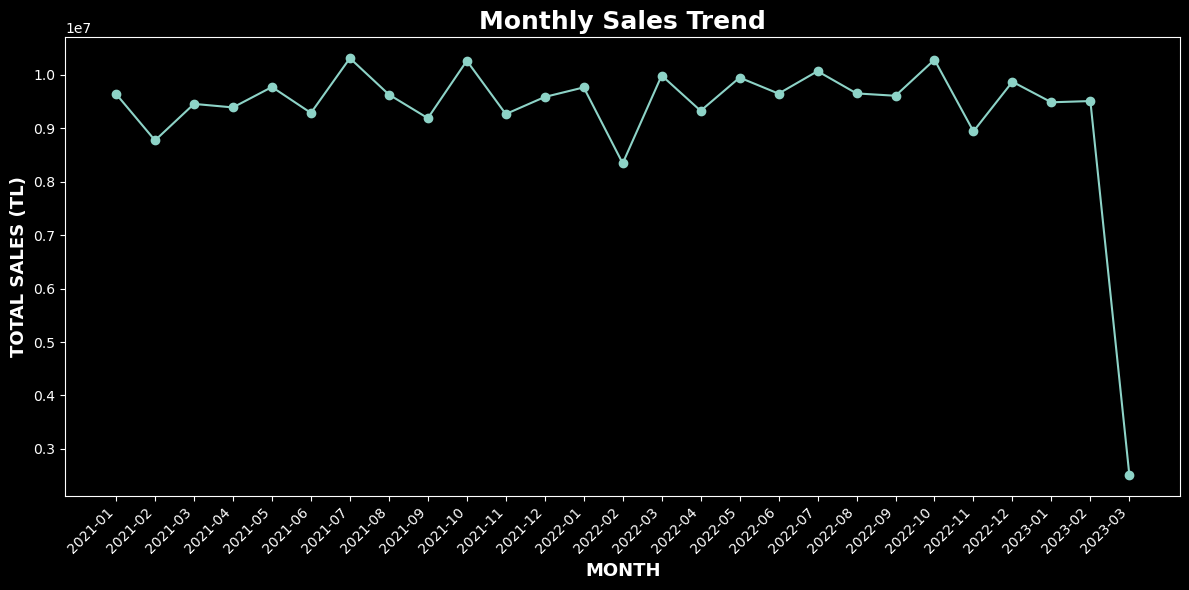

In [152]:
# Display the question we are answering
print("\nQUESTION 7\n")
print("7. Sales Over Time")
print("\nHow does total sales value change over the 2021–2023 period, and are there identifiable months or periods when customer spending increases or decreases?")

# Make sure invoice_date is stored as a date
project["invoice_date"] = pd.to_datetime(
    project["invoice_date"],
    dayfirst=True
)

# Create a month-year column
project["month_year"] = project["invoice_date"].dt.to_period("M")

# Calculate total sales for each month
monthly_sales = project.groupby("month_year").agg(
    total_sales=("total_sales", "sum")
)

# Display the monthly sales
print("\nMonthly sales:")
print(monthly_sales)

# Find the highest-sales month
highest_month = monthly_sales["total_sales"].idxmax()

# Find the lowest-sales month
lowest_month = monthly_sales["total_sales"].idxmin()

print(
    f"\nHighest sales period: {highest_month} "
    f"({monthly_sales.loc[highest_month, 'total_sales']:,.2f} TL)"
)

print(
    f"Lowest sales period: {lowest_month} "
    f"({monthly_sales.loc[lowest_month, 'total_sales']:,.2f} TL)"
)

# Create a line chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales["total_sales"],
    marker="o"
)

# Add chart title
plt.title(
    "Monthly Sales Trend",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.xlabel("MONTH", fontweight="bold", fontsize=13)
plt.ylabel("TOTAL SALES (TL)", fontweight="bold", fontsize=13)

# Rotate month labels so they do not overlap
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


QUESTION 8

8. Category Performance Across Malls

Does the strongest-performing product category remain the same across all shopping malls, or do different malls have different category preferences?

Top-performing category in each shopping mall:
        shopping_mall  category  total_sales
1         Cevahir AVM  Clothing   5706321.28
9   Emaar Square Mall  Clothing   5590490.40
17     Forum Istanbul  Clothing   5792444.24
25       Istinye Park  Clothing  11253900.24
33             Kanyon  Clothing  22609527.60
41   Mall of Istanbul  Clothing  22947417.68
49          Metrocity  Clothing  17226692.56
57       Metropol AVM  Clothing  11568084.00
65     Viaport Outlet  Clothing   5604594.16
73       Zorlu Center  Clothing   5697318.88


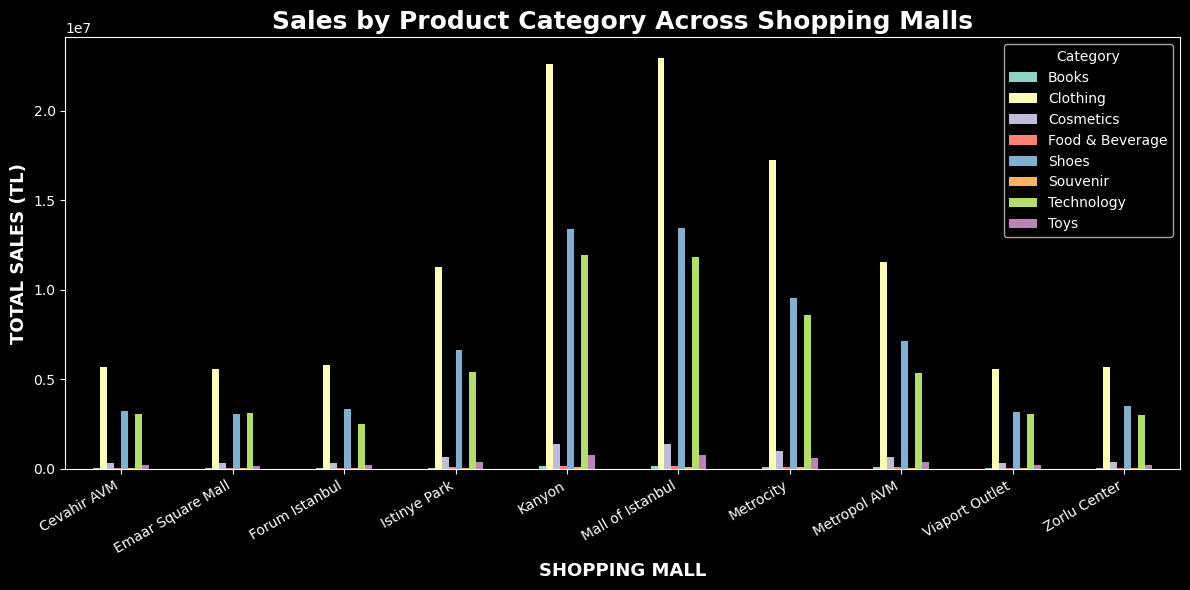

In [153]:
# Display the question we are answering
print("\nQUESTION 8\n")
print("8. Category Performance Across Malls")
print("\nDoes the strongest-performing product category remain the same across all shopping malls, or do different malls have different category preferences?")

# Group the data by shopping mall and category
# Then calculate total sales
mall_category_sales = project.groupby(
    ["shopping_mall", "category"]
).agg(
    total_sales=("total_sales", "sum")
).reset_index()

# Find the category with the highest sales in each mall
top_category_per_mall = mall_category_sales.loc[
    mall_category_sales.groupby("shopping_mall")["total_sales"].idxmax()
]

# Display the answer
print("\nTop-performing category in each shopping mall:")
print(
    top_category_per_mall[
        ["shopping_mall", "category", "total_sales"]
    ].sort_values("shopping_mall")
)

# Create a table for the chart
mall_category_pivot = mall_category_sales.pivot(
    index="shopping_mall",
    columns="category",
    values="total_sales"
).fillna(0)

# Create a bar chart
mall_category_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

# Add chart title
plt.title(
    "Sales by Product Category Across Shopping Malls",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.xlabel("SHOPPING MALL", fontweight="bold", fontsize=13)
plt.ylabel("TOTAL SALES (TL)", fontweight="bold", fontsize=13)

plt.xticks(rotation=30, ha="right")

plt.legend(title="Category")

plt.tight_layout()
plt.show()


QUESTION 9

9. Payment Method and Spending

Do customers using cash, debit cards, and credit cards differ in average transaction value and purchasing quantity?

Payment method comparison:
                average_transaction_value  average_quantity  \
payment_method                                                
Cash                          2538.579500          3.000652   
Credit Card                   2521.460129          3.007214   
Debit Card                    2519.867895          3.002988   

                total_transactions  
payment_method                      
Cash                         44447  
Credit Card                  34931  
Debit Card                   20079  


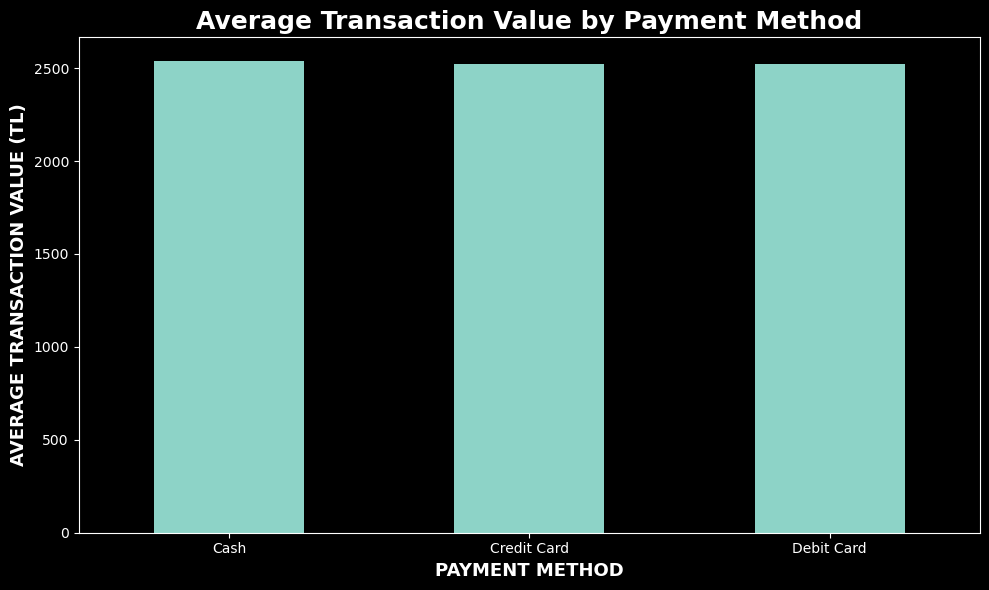

In [154]:
# Display the question we are answering
print("\nQUESTION 9\n")
print("9. Payment Method and Spending")
print("\nDo customers using cash, debit cards, and credit cards differ in average transaction value and purchasing quantity?")

# Group the data by payment method
payment_analysis = project.groupby("payment_method").agg(
    average_transaction_value=("total_sales", "mean"),
    average_quantity=("quantity", "mean"),
    total_transactions=("invoice_no", "nunique")
)

# Display the results
print("\nPayment method comparison:")
print(payment_analysis)

# Create a bar chart for average transaction value
payment_analysis["average_transaction_value"].plot(
    kind="bar",
    figsize=(10, 6)
)

# Add chart title
plt.title(
    "Average Transaction Value by Payment Method",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.xlabel("PAYMENT METHOD", fontweight="bold", fontsize=13)
plt.ylabel("AVERAGE TRANSACTION VALUE (TL)", fontweight="bold", fontsize=13)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


QUESTION 10

10. Customer Spending Concentration

What proportion of total sales value is generated by the most active customers, and how concentrated is customer spending?

The top 10% most active customers generate 10.27% of total sales.

Top 10 most active customers:
             transaction_count  total_sales
customer_id                                
C100004                      1      7502.00
C311621                      1      5401.53
C311709                      1        40.66
C311706                      1       162.64
C311701                      1       136.35
C311693                      1       187.68
C311692                      1      7502.00
C311689                      1      1200.32
C311687                      1       300.08
C311682                      1       365.94


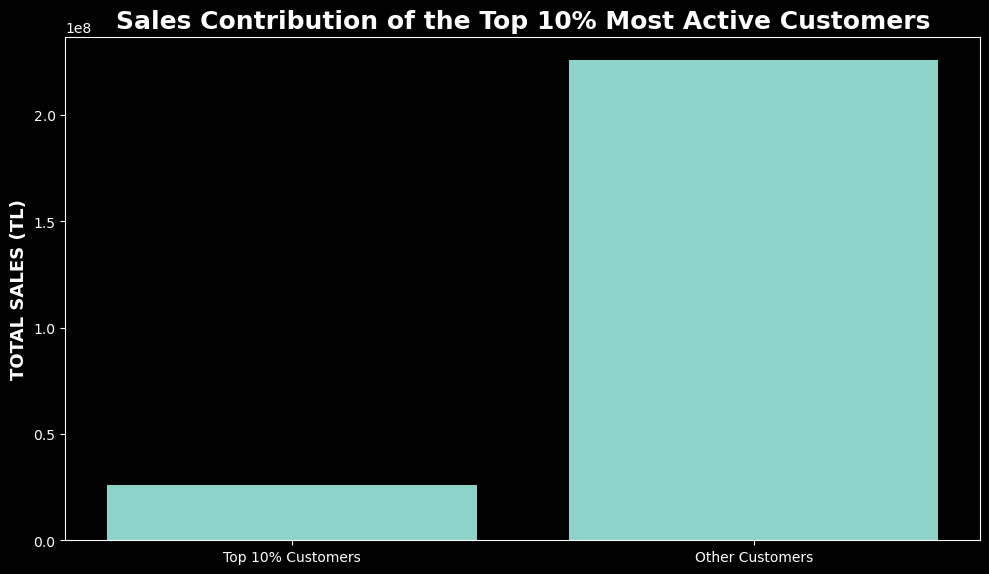

In [155]:
# Display the question we are answering
print("\nQUESTION 10\n")
print("10. Customer Spending Concentration")
print("\nWhat proportion of total sales value is generated by the most active customers, and how concentrated is customer spending?")

# Group the data by customer
# Count their transactions and calculate their total sales
customer_spending = project.groupby("customer_id").agg(
    transaction_count=("invoice_no", "nunique"),
    total_sales=("total_sales", "sum")
)

# Sort customers from the most active to the least active
customer_spending = customer_spending.sort_values(
    "transaction_count",
    ascending=False
)

# Calculate how many customers make up the top 10%
top_10_percent_count = max(
    1,
    int(len(customer_spending) * 0.10)
)

# Select the top 10% most active customers
top_customers = customer_spending.head(
    top_10_percent_count
)

# Calculate their share of total sales
sales_share = (
    top_customers["total_sales"].sum()
    / customer_spending["total_sales"].sum()
    * 100
)

# Display the answer
print(
    f"\nThe top 10% most active customers generate "
    f"{sales_share:.2f}% of total sales."
)

# Show the top 10 customers
print("\nTop 10 most active customers:")
print(customer_spending.head(10))

# Create a simple bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    ["Top 10% Customers", "Other Customers"],
    [
        top_customers["total_sales"].sum(),
        customer_spending["total_sales"].sum()
        - top_customers["total_sales"].sum()
    ]
)

# Add chart title
plt.title(
    "Sales Contribution of the Top 10% Most Active Customers",
    fontweight="bold",
    fontsize=18
)

# Label the axes
plt.ylabel("TOTAL SALES (TL)", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.show()